In [ ]:
# Paso 1: Carga de librerías y archivos
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
foods = pd.read_csv('Restaurant-Foods.csv')
customers = pd.read_csv('Restaurant-Customers.csv')
week1 = pd.read_csv('Restaurant-Week1-Sales.csv')
week2 = pd.read_csv('Restaurant-Week2-Sales.csv')

In [ ]:
# Identificar la semana de cada transacción
week1['Semana'] = 1
week2['Semana'] = 2
all_sales = pd.concat([week1, week2], ignore_index=True)

In [ ]:
# Paso 2: Validación de estructura, claves y referencias
assert foods['Food ID'].is_unique, 'Food ID debe ser único en foods'
assert customers['ID'].is_unique, 'ID debe ser único en customers'
assert all_sales['Food ID'].isin(foods['Food ID']).all(), \
 'Existen ventas con Food ID sin correspondencia'
assert all_sales['Customer ID'].isin(customers['ID']).all(), \
 'Existen ventas con Customer ID sin correspondencia'

In [ ]:
# Paso 3: Consolidación de información
full_report = (
 all_sales
 .merge(foods, on='Food ID', how='left', validate='many_to_one')
 .merge(customers, left_on='Customer ID', right_on='ID',
 how='left', validate='many_to_one')
)
# Comprobar que las uniones no dejaron datos esenciales vacíos
assert full_report['Price'].notna().all()
assert full_report['Occupation'].notna().all()


In [ ]:
# Paso 4: Construcción de indicadores (KPIs)
full_report['Ingresos'] = full_report['Price']
total_revenue = full_report['Ingresos'].sum()
weekly_revenue = full_report.groupby('Semana')['Ingresos'].sum()
weekly_records = full_report.groupby('Semana').size()
average_record_value = full_report.groupby('Semana')['Ingresos'].mean()
top_foods = (full_report.groupby('Food Item')
 .agg(Frecuencia_Compra=('Customer ID', 'count'),
 Ingresos_Totales=('Ingresos', 'sum'))
 .sort_values('Ingresos_Totales', ascending=False))

In [ ]:
# Clientes que compraron en ambas semanas
customers_w1 = set(week1['Customer ID'])
customers_w2 = set(week2['Customer ID'])
returning_customers = customers_w1.intersection(customers_w2)
recurrence_rate = (len(returning_customers) /
 week1['Customer ID'].nunique() * 100)

In [ ]:
# Gasto acumulado por ocupación (análisis agregado)
occupation_spend = (full_report.groupby('Occupation')['Ingresos']
 .sum().sort_values(ascending=False).head(5))


**Consulta complementaria en SQL:**

In [ ]:
# Paso 5: Cargar la tabla consolidada en una base SQLite temporal
connection = sqlite3.connect(':memory:')
full_report.to_sql('ventas', connection, if_exists='replace', index=False)
query = """
SELECT Semana,
 COUNT(*) AS Registros_Venta,
 SUM(Price) AS Ingresos,
 AVG(Price) AS Ingreso_Promedio
FROM ventas
GROUP BY Semana
ORDER BY Semana;
"""
weekly_summary_sql = pd.read_sql_query(query, connection)
print(weekly_summary_sql)

   Semana  Registros_Venta  Ingresos  Ingreso_Promedio
0       1              250   1962.68           7.85072
1       2              250   1923.88           7.69552


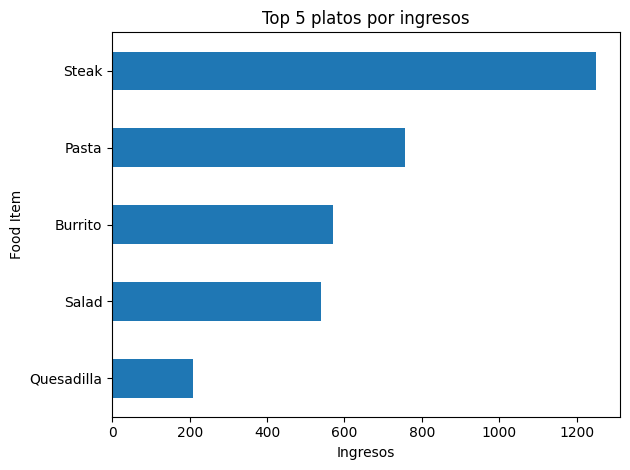

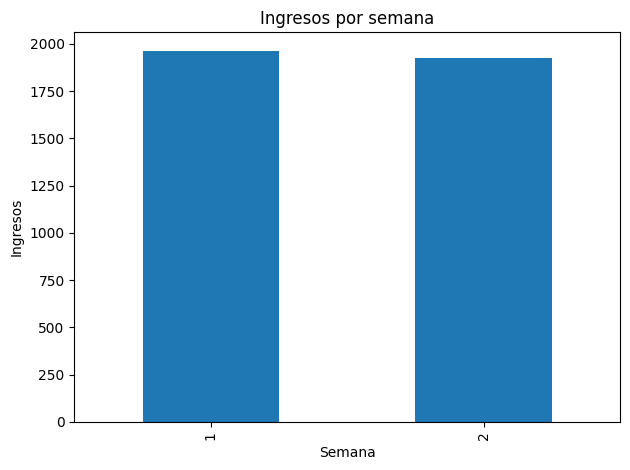

In [ ]:
# Paso 6: Visualizaciones para el informe ejecutivo
top_foods.head(5)['Ingresos_Totales'].sort_values().plot(
 kind='barh', title='Top 5 platos por ingresos')
plt.xlabel('Ingresos')
plt.tight_layout()
plt.show()
weekly_revenue.plot(kind='bar', title='Ingresos por semana')
plt.ylabel('Ingresos')
plt.tight_layout()
plt.show()
